# 深度學習與金融應用｜Unit 3
# CNN 與股票走勢圖辨識

**教師版(Colab 版,含解答與藍框註解)**

> 本版本以 **Google Colab** 為環境,學生教學主線。**本單元請務必切換到 GPU!**

---

**學習目標**
1. 理解卷積(Convolution)、池化(Pooling)、feature map 的運作,掌握 CNN「看局部形狀」的本質
2. 能看懂 filter 與 feature map 的視覺化,知道 CNN 到底「看」到什麼
3. 會用 Conv2D / MaxPooling2D / Flatten 建立影像分類模型
4. **股票走勢圖辨識**:訓練 CNN 辨識技術型態(頭肩頂/雙底/上升三角/盤整)
5. **第一次 GPU 加速體驗**:親手對照 CPU vs GPU 訓練時間,感受數十倍差異
6. **誠實比較**:合成型態能學到 90%,但 K 線圖預測漲跌仍接近隨機

**本單元三段式結構**
- 第 1~3 節:MNIST 手寫數字入門(建立 CNN 觀念地基)
- 第 4~6 節:技術型態分類(主要成就感來源,CNN 真的有用)
- 第 7 節:K 線圖漲跌分類(誠實對照組,CNN 也不是魔法)

**預計時數**:10 小時


## 第 0 節　環境與 GPU 確認(Colab)

In [2]:
# 訓練環境的檢查
import tensorflow as tf

print(f'TensorFlow 版本: {tf.__version__}')

groups = tf.config.list_physical_devices('GPU')
if groups:
  print(f'目前有GPU可用')
else:
  print(f'目前是CPU可用')

TensorFlow 版本: 2.20.0
目前是CPU可用


---
## 第 1 節　CNN 在做什麼?卷積與池化的直覺

還記得 U1 我們建的那個神經網路嗎?它是一層層的 <code>Dense</code> 疊起來的——而且每一層的每個神經元,都連到上一層<b>所有</b>的輸出。這種「每個都跟前面全部相連」的網路,就叫<b>全連接網路</b>(Fully-Connected Network,也叫 MLP)。它很萬用,但拿來處理<b>影像</b>時有個大問題。

問題出在:全連接網路只吃「一長串數字」,所以得先把影像<b>攤平</b>(例如 28×28 的圖 → 784 個數字排成一排)。原本相鄰的像素在圖上是靠在一起、彼此有關係的(它們一起構成一條邊、一個角);一攤平,這些空間上的鄰居關係就全被打散了。就像把一張照片剪成 784 個小碎片、隨機排成一列,再叫模型去認——它得多辛苦才學得回來。

<b>CNN(卷積神經網路)換了一種聰明做法:不攤平,直接保留影像的二維結構,用一個「小窗口」在圖上一格一格滑過去,專門尋找局部特徵。</b>

打個比方:與其一次盯著整張照片,CNN 像是拿一個<b>小放大鏡</b>,從左上角開始、一小塊一小塊地掃過整張圖,每掃到一處就問一句:「這一小塊像不像某個特徵?(是邊緣嗎?是角落嗎?是一段弧線嗎?)」掃完整張圖,就得到一張「哪裡出現這個特徵」的地圖。

這一節先建立兩個最核心動作的直覺——<b>卷積(用小窗口找特徵)</b>和<b>池化(把特徵濃縮、縮小圖)</b>,下面的藍框有白話解釋。建立好直覺後,第 2 節起我們就用 CNN 先認手寫數字(暖身),最後拿它來認<b>股票的技術型態</b>(頭肩頂、雙底那些形狀)。

---
## 第 2 節　MNIST 手寫數字:第一個 CNN

要驗證一個新工具好不好用,最聰明的做法是:<b>先拿一個「已知答案、乾淨又簡單」的問題來試</b>,確定它真的會動,再拿去解難的問題。所以我們不直接跳進股票走勢圖,而是先用 <b>MNIST</b> 這個經典資料集暖身。

<b>MNIST 是什麼?</b>它是深度學習界的「Hello World」:7 萬張 <b>28×28 的灰階手寫數字</b>(0~9),每張都已經標好正確答案。它最大的好處是——<b>你用肉眼就能判斷對錯</b>,所以特別適合拿來確認「我的 CNN 到底有沒有真的學到東西」。

<b>這一節會完整走一遍 CNN 的流程:</b>
1. <b>載入 + 前處理</b>:把像素值縮到 0~1、補上通道維度(下一個 cell)
2. <b>看一眼資料</b>:先把幾張數字畫出來,確認資料長得對(餵模型前的好習慣)
3. <b>疊出一個小 CNN</b>:兩個「卷積 + 池化」區塊 → 攤平(Flatten)→ 全連接 → 輸出 10 類
4. <b>訓練 + 評估</b>:看它能不能認出手寫數字——這種簡單、形狀明確的任務,CNN 通常能到 <b>99% 左右</b>

<b>為什麼要先做這個?</b>因為手寫數字有「明確又一致的形狀」,CNN 幾乎一定學得起來。等我們親眼確認這套 CNN 架構真的有效,第 4、5 節再把<b>同一套想法</b>搬去認股票的技術型態(頭肩頂、雙底)。這樣安排有個好處:日後如果模型在股票資料上表現不好,你會知道問題多半出在「<b>資料裡有沒有訊號</b>」,而不是「CNN 會不會動」——因為我們在 MNIST 上已經證明它會動了。

In [3]:
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# 載入MNIST的手寫數字資料集
# MNIST:7萬張28X28的灰階手寫數字(0~9)
# 訓練集:6萬張影像，測試集:1萬張影像
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
X_train.shape
X_test.shape

# 資料前處理-資料標準化
# 先把像素進行正規化，也就是把像素值壓到0~1之間
# 原本像素是0~255的整數，除以255讓他變成0.0~1.0的小數
# 因為神經網路對於數值範圍小又一致的輸入，學的比較穩和比較快

X_train = X_train.astype('float32')/255.0
X_test = X_test.astype('float32')/255.0

# 資料前處理-補上通道的維度
# CNN規定輸入形狀必須要是高、寬、通道，如果是影像是彩色的，那通道=3(RGB)
# 灰階影像，所以通道=1，但MNIST載入時少通道那一維，故在後面補上一維

X_train = X_train[..., None]
X_test = X_test[..., None]
print(f'訓練: {X_train.shape} 測試: {X_test.shape}')

訓練: (60000, 28, 28, 1) 測試: (10000, 28, 28, 1)


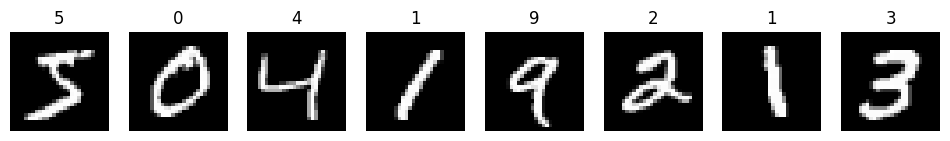

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
  ax.imshow(X_train[i, :, :, 0], cmap='gray')
  ax.set_title(str(y_train[i]))
  ax.axis('off')
plt.show()

In [5]:
tf.random.set_seed(42)

cnn = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(2),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# 模型編譯階段
cnn.compile(optimizer='adam',
      loss='sparse_categorical_crossentropy',
      metrics=['accuracy'])
print('模型Compile完成')

模型Compile完成


In [7]:
# 模型訓練階段

history = cnn.fit(X_train[:20000], y_train[:20000],
          validation_split=0.2, epochs=5,
          batch_size=64, verbose=1)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 48s 127ms/step - accuracy: 0.8778 - loss: 0.4112 - val_accuracy: 0.9582 - val_loss: 0.1369
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 26s 102ms/step - accuracy: 0.9668 - loss: 0.1109 - val_accuracy: 0.9743 - val_loss: 0.0836
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 27s 108ms/step - accuracy: 0.9778 - loss: 0.0713 - val_accuracy: 0.9783 - val_loss: 0.0752
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 39s 101ms/step - accuracy: 0.9844 - loss: 0.0511 - val_accuracy: 0.9793 - val_loss: 0.0690
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 34s 73ms/step - accuracy: 0.9881 - loss: 0.0394 - val_accuracy: 0.9805 - val_loss: 0.0669


In [8]:
# 模型測試階段
test_loss, test_acc = cnn.evaluate(X_test, y_test, verbose=0)
print(f'MNIST 測試準確率: {test_acc:.3f}')

MNIST 測試準確率: 0.982


測試集共: 10000 張，答錯 183 張，錯誤率:0.018


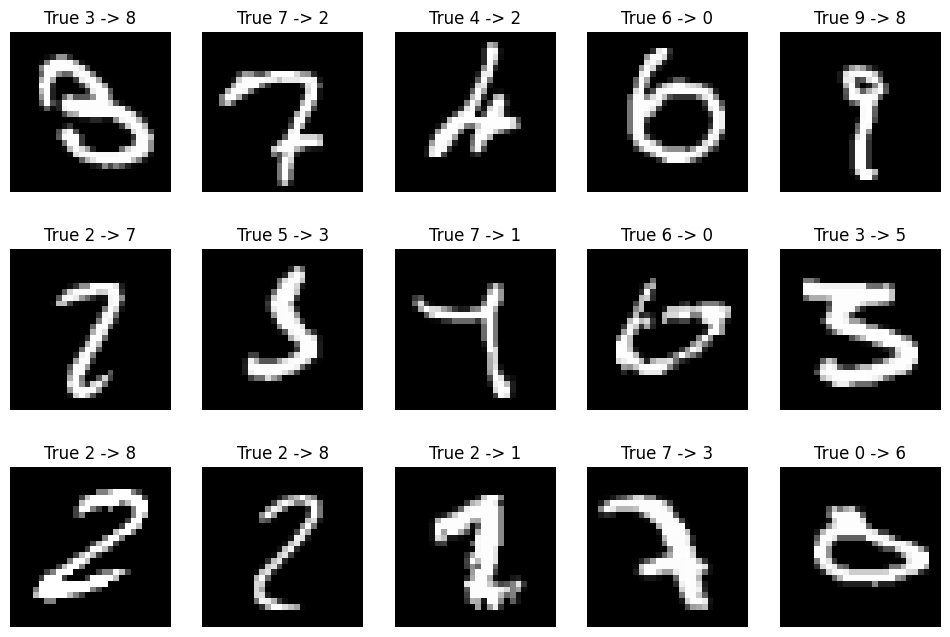

In [9]:
# 把錯誤的圖片抓出來

# 1. 取得模型對每張測試圖的預測
probs = cnn.predict(X_test, verbose=0)
y_pred = probs.argmax(axis=1) # 取機率最大的類別當作預測答案

# 2. 找出預測!=真實的位置
wrong_idx = np.where(y_pred != y_test)[0]
print(f'測試集共: {len(X_test)} 張，答錯 {len(wrong_idx)} 張，錯誤率:\
{len(wrong_idx)/len(X_test):.3f}')

# 3. 把前15張錯誤的圖畫出來
n_show = min(15, len(wrong_idx))
fig, axes = plt.subplots(3, 5, figsize=(12, 8))
for ax, i in zip(axes.flat, wrong_idx[:n_show]):
  ax.imshow(X_test[i].reshape(28, 28), cmap='gray')
  conf = probs[i].max()
  ax.set_title(f'True {y_test[i]} -> {y_pred[i]}')
  ax.axis('off')
plt.show()

---
## 第 3 節　看看 CNN 到底「看」到什麼:filter 與 feature map 視覺化

神經網路常被說成「黑盒子」——但 CNN 有個很棒的特點:<b>它中間的計算結果是可以「畫出來看」的</b>。這一節我們就打開盒子,親眼看看 CNN 到底在看什麼。

先認識兩個名詞:
• <b>filter(濾鏡 / 卷積核)</b>:就是第 1 節說的那個「小窗口」。每個 filter 專門偵測某一種局部特徵(例如水平邊緣、垂直線、某種弧角)。我們模型的第一層有 <b>32 個 filter</b>,等於 32 種不同的「特徵偵測器」。
• <b>feature map(特徵圖)</b>:一個 filter 滑過整張圖之後得到的結果。它其實是一張「<b>哪裡出現了這個特徵</b>」的地圖——某個位置越亮,就代表那裡越符合這個 filter 想找的東西。

<b>這一節要做的事:</b>拿一張測試圖(一個手寫數字),餵進剛訓練好的 CNN,把<b>第一層 32 個 filter 各自產生的 feature map 畫出來</b>看個清楚。

<b>看的時候請特別注意一件事:</b>這些 filter <b>沒有人事先告訴它們該抓什麼</b>——它們是在訓練過程中<b>自己學會</b>的。這正是深度學習最迷人、也和傳統機器學習差最多的地方:ML 要人工設計特徵(例如各種技術指標),CNN 則能<b>自動</b>從資料裡學出「該看哪些特徵」。等一下辨識股票技術型態,靠的就是這個能力。

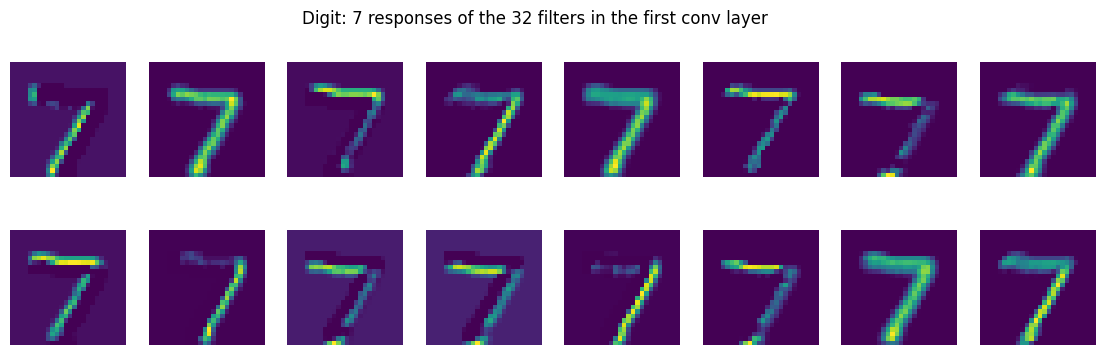

In [10]:
from tensorflow.keras import Model

# cnn.layers[0]是第一個Conv2D的output，我們要看這一層算完的feature maps
layer_outputs = [cnn.layers[0].output]

# 用原本的輸入接到第一層的輸出，重新組成新的小模型activation_model
# 接下來再餵一張圖進去，這個小模型就會回傳第一層的feature map
activation_model = Model(inputs=cnn.inputs, outputs=layer_outputs)

sample = X_test[0:1] # 取一張測試圖
# 模型會使用predict來回傳1張26x26的圖，再產生32張為了filter而生的小圖
# 為什麼是26而不是28，因為卷積神經網路沒有補邊，所以四周的大小會各少1
feautre_map = activation_model.predict(sample, verbose=0)[0]

# 畫出前16張的feature map
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat): # axes.flat 把2x8的子圖攤平，依序取用
  # feautre_map[:, :, i]是第i個filter的圖片，用顏色亮暗來表示特徵的強弱
  ax.imshow(feautre_map[:, :, i], cmap='viridis')
  ax.axis('off') # 關掉座標軸，讓畫面乾淨
plt.suptitle(f'Digit: {y_test[0]} responses of the 32 filters in the first conv layer')
plt.show()

---
## 第 4 節　股票走勢圖辨識(一):生成技術型態資料集

現在進入本單元的重頭戲:教 CNN 看「走勢圖的形狀」。技術分析裡,交易者常把某些反覆出現的形狀叫做「<b>技術型態</b>」,並認為它們可能暗示後續走勢。這一節我們挑四種經典型態當作分類目標:

• <b>頭肩頂</b>:三個高點,中間那個最高(頭)、兩側較低(肩),常被視為「見頂反轉」的形狀。<br>
• <b>雙底</b>:兩個差不多深的低點,長得像英文字母 W,常被視為「打底反轉」。<br>
• <b>上升三角</b>:低點一底比一底高、但高點被一條水平線壓住,偏向「多方整理」。<br>
• <b>盤整</b>:沒有明顯方向,只在一個區間裡小幅上下震盪。

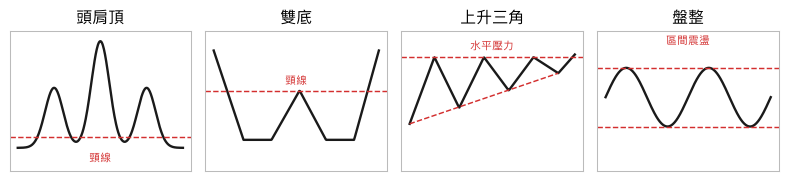<br><i>▲ 四種型態的教科書式示意(紅色虛線為頸線 / 趨勢線 / 壓力支撐等輔助線)。注意:實際合成給 CNN 的訓練圖只有黑色價格曲線、會帶雜訊,且<b>不含</b>這些輔助線。</i>

<b>為什麼用「合成」資料,而不是真實線圖?</b>三個理由:
1. <b>標籤很乾淨</b>:自己畫的圖,當然知道它是哪一種型態——不必人工標註幾千張真圖。
2. <b>可控、可重現</b>:要多少張、雜訊多大都能調;學生也能自己重新生成一模一樣的資料。
3. <b>沒有版權問題</b>,而且能做一件很重要的事:<b>把「CNN 會不會認形狀」和「真實市場有沒有訊號」這兩件事分開來看</b>。

<b>這一節的第一步</b>:寫一個函式,用數學曲線 + 隨機雜訊<b>合成</b>帶標籤的走勢序列,再把每條序列畫成一張 64×64 的灰階圖,當作 CNN 的輸入。因為型態的形狀「明確又一致」,CNN 應該學得很好(第 5 節會看到約 <b>90%</b> 準確率)——這正好和第 6 節「用真實 K 線圖預測漲跌」接近隨機的結果,形成強烈對比。

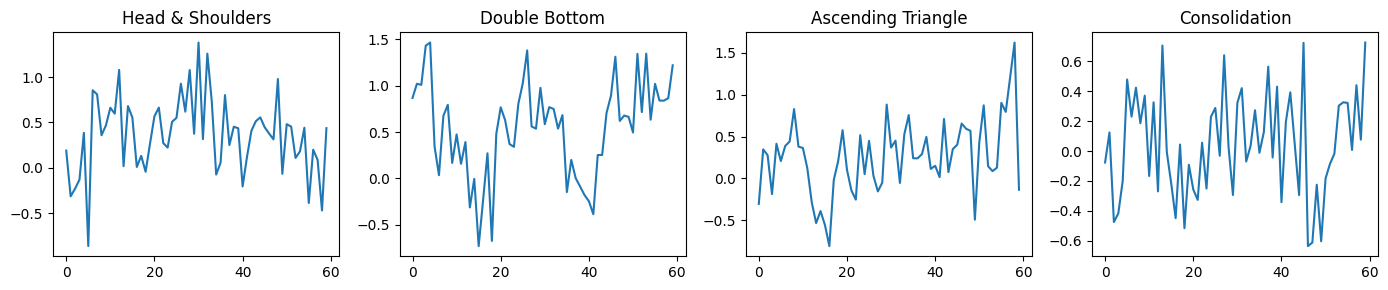

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image   # Pillow:用來把圖統一縮放成 64×64

IMG = 64  # 最後要餵給 CNN 的影像大小:64×64

# 四種型態的名稱(順序 = 標籤 0,1,2,3),就是分類的 4 個類別
PATTERN_NAMES = ['Head & Shoulders', 'Double Bottom', 'Ascending Triangle', 'Consolidation']


def make_pattern(kind, length=60, noise=0.35):
    """合成「一條」帶指定型態的價格序列(長度 length 的一維陣列)。
    kind:要哪一種型態(0~3);noise:疊加的隨機雜訊強度(越大越像真實、也越難認)。"""
    x = np.linspace(0, 1, length)            # x 從 0 到 1,均勻切 length 個點(當作時間軸)
    # 每次都隨機左右平移一點點 → 同一種型態不會長得一模一樣。
    # 這是一種「資料增強」,逼 CNN 去學「形狀」而不是死背「位置」。
    shift = np.random.uniform(-0.05, 0.05)
    if kind == 0:      # 頭肩頂:三個「鐘形凸起」= 左肩、頭(最高)、右肩
        # np.exp(-((x-中心)**2)/寬度) 是一個高斯鐘形;乘上去的係數 = 高度。
        y = (np.exp(-((x-0.2-shift)**2)/0.012)*0.5     # 左肩(較矮)
             + np.exp(-((x-0.5-shift)**2)/0.01)*0.85    # 頭(最高)
             + np.exp(-((x-0.8-shift)**2)/0.012)*0.5)   # 右肩(較矮)
    elif kind == 1:    # 雙底:兩個往下的「鐘形凹陷」(前面加負號),再整體抬高 → 像 W
        y = (-np.exp(-((x-0.3-shift)**2)/0.01)*0.85
             - np.exp(-((x-0.7-shift)**2)/0.01)*0.85 + 0.85)
    elif kind == 2:    # 上升三角:以一條上升斜線(0.5*x)為主,再加「越後面越小」的抖動
        y = 0.5*x + 0.2*np.sin(x*20)*(1-x)
    else:              # 盤整:低振幅的來回震盪(小小的 sin 波),沒有明顯方向
        y = 0.15*np.sin(x*15)
    # 最後疊上高斯雜訊,讓每條線都不完美、更貼近真實走勢(也讓題目有點難度)
    return y + np.random.normal(0, noise, length)


def series_to_image(y):
    """把「一條價格序列」畫成折線圖,再轉成 64×64 的灰階影像陣列(值 0~1)。
    因為 CNN 吃的是「影像」,所以要先把數字序列「畫成圖」。"""
    # 開一張小畫布:figsize × dpi 決定像素數。add_axes([0,0,1,1]) 讓折線圖佔滿整張、沒有邊白。
    fig = plt.figure(figsize=(1.5, 1.5), dpi=IMG/1.5)
    ax = fig.add_axes([0, 0, 1, 1]); ax.axis('off')    # 關掉座標軸,只留下線條本身
    ax.plot(y, color='black', linewidth=1.5)
    ax.set_ylim(y.min()-0.3, y.max()+0.3)              # 上下各留點邊,線不會貼到邊緣被切掉
    fig.canvas.draw()                                   # 真的把圖畫到記憶體裡的畫布上
    # 從畫布把「像素」讀出來:buffer_rgba() 給一長串 RGBA 位元組,reshape 回 (高, 寬, 4)
    buf = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
    buf = buf.reshape(fig.canvas.get_width_height()[::-1] + (4,))
    gray = buf[:, :, :3].mean(axis=2) / 255.0           # 取 RGB 三通道平均 → 灰階;/255 縮到 0~1
    plt.close(fig)                                       # 關掉畫布釋放記憶體(要畫很多張時很重要)
    # 用 Pillow 把影像縮放成統一的 64×64,再轉回 0~1 的陣列回傳
    return np.array(Image.fromarray((gray*255).astype(np.uint8)).resize((IMG, IMG)))/255.0


# --- 先畫四種型態各一條,看看長什麼樣(這是帶雜訊的實際樣本,不是上面那張教科書示意圖)---
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for k in range(4):
    axes[k].plot(make_pattern(k)); axes[k].set_title(PATTERN_NAMES[k])
plt.tight_layout(); plt.show()

In [12]:
from re import split
# 生成每一類各150張，共4x150=600張
N_per = 150
X_pat, y_pat = [], [] # 先用list收集資料，最後再一次轉成numpy陣列
for kind in range(4): # 4種型態
  for _ in range(N_per): # 每種型態各生成150張型態，每張都不同，因為平移和雜訊都是隨機的
    X_pat.append(series_to_image(make_pattern(kind))) # 生成一條序列，轉成64x64的灰階圖
    y_pat.append(kind) # 這張圖的標籤

X_pat = np.array(X_pat)[..., None] # 把圖的形狀變成(600, 64, 64, 1)，也就是(張數，高，寬， 維度)
y_pat = np.array(y_pat) # 標籤陣列和形狀 (600, 1)
X_pat

# 順序打亂，再切分成訓練和測試
idx = np.random.permutation(len(X_pat)) # 產生一組打亂的索引(0~599)
X_pat, y_pat = X_pat[idx], y_pat[idx] # 用同一組索引同時打亂X和y
split = int(len(X_pat)*0.8) # 前80%訓練，後20%測試
Xtr_p, Xte_p = X_pat[:split], X_pat[split:]
ytr_p, yte_p = y_pat[:split], y_pat[split:]
# np.bincount() 數各類各幾型態資料集: {X_pat.shape}, 每類數張，確認四類的數量差不多
print(f'量: {np.bincount(y_pat)}')


量: [150 150 150 150]


---
## 第 5 節　股票走勢圖辨識(二):訓練型態分類 CNN

In [13]:
tf.random.set_seed(42) # 固定隨機種子，讓結果可以重現

# 準備模型階段
pattern_cnn = keras.Sequential([
        keras.Input(shape=(IMG, IMG, 1)), # 輸入是一張64x64的灰階走勢圖
        # 卷積跟池化層，一樣是透過Conv2D找特徵，然後池化縮小特徵形成特徵地圖
        layers.Conv2D(16, 3, activation='relu'),
        layers.MaxPool2D(2),
        layers.Conv2D(32, 3, activation='relu'),
        layers.MaxPool2D(2),
        # 攤平層
        layers.Flatten(),
        # 全連結層做連接
        layers.Dense(64, activation='relu'),
        layers.Dense(4, activation='softmax')
])

# 模型編譯階段
pattern_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
          metrics=['accuracy'])

# 模型訓練階段
pattern_cnn.fit(Xtr_p, ytr_p, validation_split=0.2, epochs=15, batch_size=16, verbose=1)


Epoch 1/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 142ms/step - accuracy: 0.3151 - loss: 1.3644 - val_accuracy: 0.4062 - val_loss: 1.1667
Epoch 2/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.7370 - loss: 0.8183 - val_accuracy: 0.8750 - val_loss: 0.4305
Epoch 3/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.8854 - loss: 0.3485 - val_accuracy: 0.9375 - val_loss: 0.2107
Epoch 4/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.8932 - loss: 0.2449 - val_accuracy: 0.8750 - val_loss: 0.2879
Epoch 5/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.9375 - loss: 0.1641 - val_accuracy: 0.9062 - val_loss: 0.2163
Epoch 6/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.9635 - loss: 0.1073 - val_accuracy: 0.9167 - val_loss: 0.2366
Epoch 7/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.9714 - loss: 0.0958 - val_accuracy: 0.9271 - val_loss: 0.2693
Epoch 8/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.9609 - loss: 0.0880 - val_accuracy: 0.9271 - 

In [14]:
# 拿測試集來測試模型
loss, pat_acc = pattern_cnn.evaluate(Xte_p, yte_p, verbose=0)
print(f'損失:{loss:.3f}, 型態分類的準確率:{pat_acc:.3f}')

損失:0.334, 型態分類的準確率:0.908


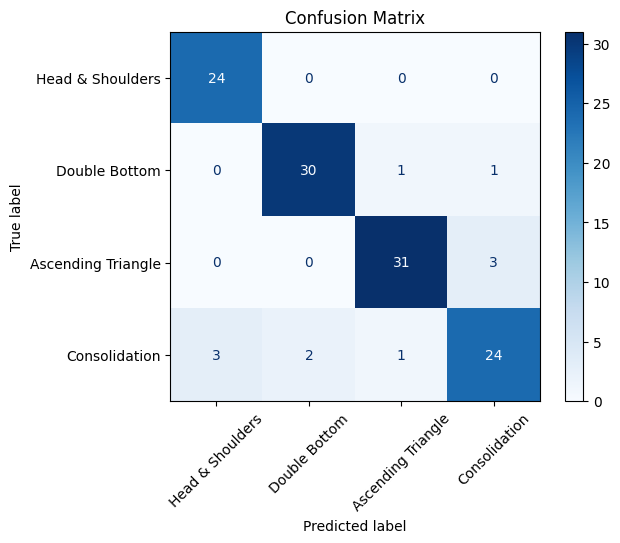

In [15]:
# 利用混淆矩陣來看清楚模型把那些型態搞混了

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

pred = pattern_cnn.predict(Xte_p, verbose=0).argmax(axis=1)
cm = confusion_matrix(yte_p, pred)
cm
ConfusionMatrixDisplay(cm, display_labels=['Head & Shoulders', 'Double Bottom', 'Ascending Triangle', 'Consolidation']).plot(cmap='Blues')
plt.xticks(rotation=45)
plt.title('Confusion Matrix')
plt.show()

---
## 第 6 節　股票走勢圖辨識(三):K 線圖預測漲跌 —— 誠實對照組

型態分類這麼成功,那用 CNN 看真實的 K 線圖,能不能預測隔日漲跌?
我們用 `mplfinance` 把前 20 日 OHLC 畫成 K 線圖,標籤是隔日漲或跌。


In [16]:
# !pip install mplfinance
import pandas as pd
import yfinance as yf
import mplfinance as mpf

# 直接用yfinance抓國巨2327.TW近兩年的OHLC
ticker = '2327.TW'
df = yf.download(ticker, period='2y', progress=False, auto_adjust=True)
# 做欄位攤平的動作
if isinstance(df.columns, pd.MultiIndex):
  df.columns = df.columns.get_level_values(0)
ohlc = df[['Open', 'High', 'Low', 'Close']]
ohlc

# 把每20天的K線圖做成一張影像+標籤(隔日的漲跌)當作CNN的訓練資料
def kline_to_image(window_df):
  fig, _ = mpf.plot(window_df, type='candle', style='yahoo',
            axisoff=True, returnfig=True, figsize=(1.5, 1.5))
  fig.canvas.draw() # 把上面的圖畫寫進去記憶體裡面的畫布
  # 從記憶體裡面的畫布讀取像素RGBA，在重塑形狀成(高, 寬, 4)
  buf = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
  buf = buf.reshape(fig.canvas.get_width_height()[::-1] + (4,))
  gray = buf[:,:, :3].mean(axis=2) / 255.0
  plt.close(fig)
  return np.array(Image.fromarray((gray*255).astype(np.uint8)).resize((IMG, IMG)))/255.0

WIN = 20
close_arr = ohlc['Close'].values # 收盤價陣列，用來計算隔日漲跌
X_kline, y_kline = [], []

for i in range(WIN, min(WIN+200, len(ohlc)-1)):
  window = ohlc.iloc[i-WIN:i]
  X_kline.append(kline_to_image(window))
  ret_next = (close_arr[i] - close_arr[i-1]) / close_arr[i-1] # 計算隔日報酬
  y_kline.append(1 if ret_next > 0 else 0) # 只要ret>0就是1，反之就是0

X_kline = np.array(X_kline)[..., None]
y_kline = np.array(y_kline)

# 切分資料為訓練集和測試集
sp = int(len(X_kline)*0.8)
Xtr_k, Xte_k = X_kline[:sp], X_kline[sp:]
ytr_k, yte_k = y_kline[:sp], y_kline[sp:]
# np.bincount() 數各類各幾型態資料集: {X_pat.shape}, 每類數張，確認四類的數量差不多
print(f'K線圖資料集: {X_kline.shape}, 漲跌分布: {np.bincount(y_kline)}')

K線圖資料集: (200, 64, 64, 1), 漲跌分布: [110  90]


In [17]:
# 準備模型

tf.random.set_seed(42)
kline_cnn = keras.Sequential([
        keras.Input(shape=(IMG, IMG, 1)),
        layers.Conv2D(16, 3, activation='relu'),
        layers.MaxPool2D(2),
        layers.Conv2D(32, 3, activation='relu'),
        layers.MaxPool2D(2),
        # 攤平層
        layers.Flatten(),
        # 全連結層做連接
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='sigmoid')
])

# 模型編譯
kline_cnn.compile(optimizer='adam', loss='binary_crossentropy',
          metrics=['accuracy'])

 # 模型訓練階段
kline_cnn.fit(Xtr_k, ytr_k, validation_split=0.2, epochs=15, batch_size=16, verbose=1)

Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 162ms/step - accuracy: 0.5156 - loss: 0.7046 - val_accuracy: 0.5625 - val_loss: 0.6846
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.4922 - loss: 0.6962 - val_accuracy: 0.5625 - val_loss: 0.6912
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.5469 - loss: 0.6908 - val_accuracy: 0.5625 - val_loss: 0.6896
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.5469 - loss: 0.6885 - val_accuracy: 0.5625 - val_loss: 0.6870
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.5469 - loss: 0.6862 - val_accuracy: 0.5625 - val_loss: 0.6870
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.5469 - loss: 0.6854 - val_accuracy: 0.5625 - val_loss: 0.6884
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.5469 - loss: 0.6822 - val_accuracy: 0.5625 - val_loss: 0.6900
Epoch 8/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.5625 - loss: 0.6791 - val_accuracy: 0.5625 - val_loss: 0.6943

In [18]:
# 拿測試集來測試模型
loss, kline_acc = kline_cnn.evaluate(Xte_k, yte_k, verbose=0)
print(f'損失:{loss:.3f}, 準確率:{kline_acc:.3f}')
baseline = max(yte_k.mean(), 1- yte_k.mean())
print(f'Baseline: {baseline:.3f}')
print(f'差距: {kline_acc - baseline:.3f}')


損失:0.683, 準確率:0.575
Baseline: 0.550
差距: 0.025


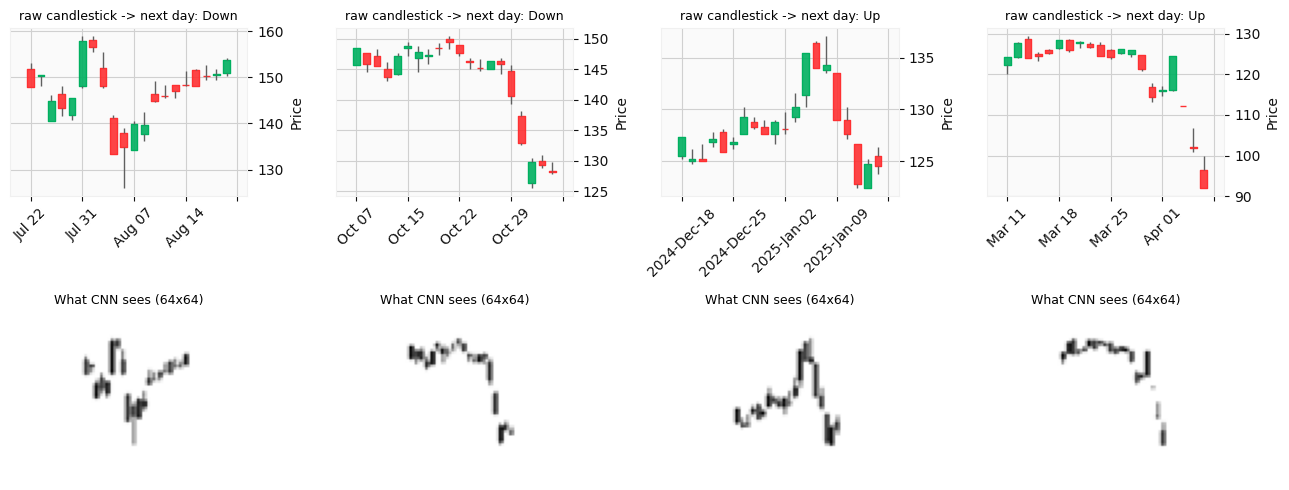

In [19]:
show_idx = [0, 50, 100, 150] # 從資料集裡挑4個樣本
fig = plt.figure(figsize=(13, 5))
for col, k in enumerate(show_idx):
  win = ohlc.iloc[k:k+WIN]
  lab = 'Up' if y_kline[k] == 1 else 'Down' # 隔日漲跌標籤
  ax1 = fig.add_subplot(2, 4, col + 1)
  mpf.plot(win, type='candle', style='yahoo', ax=ax1)
  ax1.set_title(f'raw candlestick -> next day: {lab}', fontsize=9)

  ax2 = fig.add_subplot(2, 4, col + 5)
  ax2.imshow(X_kline[k, :, :, 0], cmap='gray')
  ax2.axis('off')
  ax2.set_title('What CNN sees (64x64)', fontsize=9)
plt.tight_layout()
plt.show()


---

# 課堂練習｜用 CNN 辨識胸腔 X 光(正常 vs 肺炎)

這份練習用 CNN 判斷**真實的胸腔 X 光**是「正常」還是「肺炎」。肺炎在 X 光上會呈現白色的浸潤(訊號清楚),所以 CNN 學得起來、準確率很高。

> 可以和 U3 第 6 節「用 K 線圖預測隔日漲跌」(接近隨機、沒有訊號)對照:同樣是 CNN,X 光學得起來、K 線學不動——再次印證本課的靈魂:**模型能力的上限,取決於資料裡有沒有訊號。**

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

IMG = 64 # 影像大小 64×64
rng = np.random.default_rng(42) # 固定亂數種子,結果可重現
print("TensorFlow 版本:", tf.__version__)

TensorFlow 版本: 2.20.0


In [23]:
# 直接Kereas內建工具一次讀完完整的資料夾
import os

Data_dir = '/content/drive/MyDrive/Colab Notebooks/Mol/2026/Deep_Learning/chest_xray/train'


train_ds = tf.keras.utils.image_dataset_from_directory(
    Data_dir,
    color_mode='grayscale',
    image_size=(IMG, IMG),
    batch_size=None,
    shuffle=True
)

X_xray = []
y_xray = []
for img, label in train_ds:
  X_xray.append(img.numpy())
  y_xray.append(label.numpy())
X_xray = np.array(X_xray) / 255.0
y_xray = np.array(y_xray)
print(f'讀取本機真實X光: {Data_dir}')

# 切分訓練集和測試集
sp = int(len(X_xray)*0.8)
Xtr, Xte = X_xray[:sp], X_xray[sp:]
ytr, yte = y_xray[:sp], y_xray[sp:]

print(f'X 光資料集: {X_xray.shape} 分布(正常|肺炎)', np.bincount(y_xray))

Found 5216 files belonging to 2 classes.
讀取本機真實X光: /content/drive/MyDrive/Colab Notebooks/Mol/2026/Deep_Learning/chest_xray/train
X 光資料集: (5216, 64, 64, 1) 分布(正常|肺炎) [1341 3875]


In [27]:
# 資料標準化
mu, sd = Xtr.mean(), Xtr.std()
Xtr_s = (Xtr - mu) / sd
Xte_s = (Xte - mu) / sd

# 固定隨機種子
tf.random.set_seed(42)

# 設置模型
xray_cnn = keras.Sequential([
      keras.Input(shape=(IMG, IMG, 1)),
      layers.Conv2D(16, 3, activation='relu'),
      layers.MaxPool2D(2),
      layers.Conv2D(32, 3, activation='relu'),
      layers.MaxPool2D(2),
      # 攤平層
      layers.Flatten(),
      # 全連結層做連接
      layers.Dense(64, activation='relu'),
      layers.Dense(1, activation='sigmoid')
])


# 模型編譯
xray_cnn.compile(optimizer='adam', loss='binary_crossentropy',
          metrics=['accuracy'])

 # 模型訓練階段
xray_cnn.fit(Xtr_s, ytr, validation_split=0.2, epochs=15, batch_size=32, verbose=1)


Epoch 1/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 15s 100ms/step - accuracy: 0.9212 - loss: 0.2023 - val_accuracy: 0.9713 - val_loss: 0.0825
Epoch 2/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 22s 114ms/step - accuracy: 0.9640 - loss: 0.1005 - val_accuracy: 0.9665 - val_loss: 0.0891
Epoch 3/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - accuracy: 0.9694 - loss: 0.0841 - val_accuracy: 0.9689 - val_loss: 0.0821
Epoch 4/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 12s 104ms/step - accuracy: 0.9694 - loss: 0.0804 - val_accuracy: 0.9784 - val_loss: 0.0649
Epoch 5/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 21s 106ms/step - accuracy: 0.9748 - loss: 0.0637 - val_accuracy: 0.9808 - val_loss: 0.0586
Epoch 6/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 27s 167ms/step - accuracy: 0.9778 - loss: 0.0581 - val_accuracy: 0.9713 - val_loss: 0.0688
Epoch 7/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 12s 110ms/step - accuracy: 0.9817 - loss: 0.0471 - val_accuracy: 0.9737 - val_loss: 0.0629
Epoch 8/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 21s 111ms/step - accuracy: 0.9898 - loss: 0.0

In [28]:
# 拿測試集來測試模型
loss, xray_acc = xray_cnn.evaluate(Xte_s, yte, verbose=0)
print(f'損失:{loss:.3f}, 準確率:{xray_acc:.3f}')
# baseline = max(yte_k.mean(), 1- yte_k.mean())
# print(f'Baseline: {baseline:.3f}')
# print(f'差距: {kline_acc - baseline:.3f}')


損失:0.095, 準確率:0.971
